# Lab 7

In [3]:
import torch
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision import models
import torch.optim as optim
import matplotlib.pyplot as plt
import pdb
import matplotlib.pyplot as plt

In [2]:
transform = transforms.Compose([
transforms.Resize((224, 224)),
transforms.ToTensor(),
transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229,
0.224, 0.225])
])

In [6]:
dataset = datasets.ImageFolder(root=r"C:\Users\Isma Imtiaz\OneDrive\Desktop\New Folder",
transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [4]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False
    
num_ftrs = model.fc.in_features
model.fc = torch.nn.Linear(num_ftrs, 2)

optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

In [5]:
epochs= 40
transfer_learning_loss=[]
for i in range(epochs):
    running_loss = 0 
    for data,labels in dataloader:
        optimizer.zero_grad()
        preds = model(data)
        loss = criterion(preds, labels)
        running_loss=running_loss + loss.item()
        loss.backward()
    transfer_learning_loss.append(running_loss)
    if (i%5==0):
        print(f'Epoch {i+1}, Loss: {running_loss/len(dataset)}')     

Epoch 1, Loss: 0.02447939424191491
Epoch 6, Loss: 0.02402414255223032
Epoch 11, Loss: 0.024117306632510688
Epoch 16, Loss: 0.024467975911447556
Epoch 21, Loss: 0.024126460996724792
Epoch 26, Loss: 0.02422024840015476
Epoch 31, Loss: 0.024680246741084728
Epoch 36, Loss: 0.02436308992111077


# Custom Model

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim

class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()
        
        # Define convolutional layers
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=7, stride=2, padding=3),  # Similar to ResNet conv1
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Define fully connected layers
        self.fc_layers = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # Global Average Pooling like ResNet
            nn.Flatten(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 2)  # Binary classification (2 classes)
        )
        
    def forward(self, x):
        x = self.conv_layers(x)  # Pass through convolutional layers
        x = self.fc_layers(x)    # Pass through fully connected layers
        return x

# Instantiate the model
model = CustomCNN()

# Define the optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Example summary of the model
print(model)


CustomCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats

In [7]:
epochs= 40
transfer_learning_loss=[]
for i in range(epochs):
    running_loss = 0 
    for data,labels in dataloader:
        optimizer.zero_grad()
        preds = model(data)
        loss = criterion(preds, labels)
        running_loss=running_loss + loss.item()
        loss.backward()
    transfer_learning_loss.append(running_loss)
    if (i%5==0):
        print(f'Epoch {i+1}, Loss: {running_loss/len(dataset)}')     

Epoch 1, Loss: 0.023560545202028955
Epoch 6, Loss: 0.023288548497830408
Epoch 11, Loss: 0.024024393093788017
Epoch 16, Loss: 0.024149645688170095
Epoch 21, Loss: 0.024168943449602288
Epoch 26, Loss: 0.023973213414014396
Epoch 31, Loss: 0.023529825574260647
Epoch 36, Loss: 0.024428620681924335


# Data Augmentation

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define the data augmentation transforms
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),           # Randomly flip images horizontally
    transforms.RandomRotation(degrees=15),            # Random rotation between -15 to 15 degrees
    transforms.RandomResizedCrop(size=(224, 224)),     # Randomly crop and resize images to 224x224 (for ResNet-like input)
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Random color jitter
    transforms.ToTensor(),                            # Convert images to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])    # Normalize with ImageNet statistics
])

# Load the dataset using ImageFolder with the specified transforms
dataset = datasets.ImageFolder(root=r"C:\Users\Isma Imtiaz\OneDrive\Desktop\New Folder",
                               transform=transform)

# Split the dataset into train and validation sets
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

# Create the DataLoader for train and test sets
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

# Check the size of the datasets
print(f'Train set size: {len(train_dataset)}')
print(f'Test set size: {len(test_dataset)}')


Train set size: 94
Test set size: 24


# Pretrained

In [4]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False
    
num_ftrs = model.fc.in_features
model.fc = torch.nn.Linear(num_ftrs, 2)

optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

In [7]:
epochs= 40
finetuning_loss=[]
for i in range(epochs):
    running_loss = 0 
    for data,labels in dataloader:
        optimizer.zero_grad()
        preds = model(data)
        loss = criterion(preds, labels)
        running_loss=running_loss + loss.item()
        loss.backward()
    finetuning_loss.append(running_loss)
    if (i%5==0):
        print(f'Epoch {i+1}, Loss: {running_loss/len(dataset)}')

Epoch 1, Loss: 0.024494120630167298
Epoch 6, Loss: 0.02644909488952766
Epoch 11, Loss: 0.024686057688826223
Epoch 16, Loss: 0.025302984956967627
Epoch 21, Loss: 0.025478869171465857
Epoch 26, Loss: 0.024799083754167717
Epoch 31, Loss: 0.02447915885408046
Epoch 36, Loss: 0.025584627511137624


# Custom

In [10]:
model = CustomCNN()

# Define the optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=0.0003)
criterion = nn.CrossEntropyLoss()

# Example summary of the model
print(model)

CustomCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats

In [11]:
epochs= 40
transfer_learning_loss=[]
for i in range(epochs):
    running_loss = 0 
    for data,labels in dataloader:
        optimizer.zero_grad()
        preds = model(data)
        loss = criterion(preds, labels)
        running_loss=running_loss + loss.item()
        loss.backward()
    transfer_learning_loss.append(running_loss)
    if (i%5==0):
        print(f'Epoch {i+1}, Loss: {running_loss/len(dataset)}')     

Epoch 1, Loss: 0.0252888914892229
Epoch 6, Loss: 0.02434316732115665
Epoch 11, Loss: 0.024940808950844457
Epoch 16, Loss: 0.024307173692573934
Epoch 21, Loss: 0.024983900078272416
Epoch 26, Loss: 0.023746787491491287
Epoch 31, Loss: 0.024365363484722073
Epoch 36, Loss: 0.025481707968954312


# Task 2

In [17]:
import torch
import cv2
from torchvision import transforms, models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = models.mobilenet_v2(pretrained=True)
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, 2)  
model = model.to(device)
model.eval()  

class_names = ['Disney', 'Ghibli']

preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def classify_video_frames(video_path, frame_sampling_rate=10):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video {video_path}")
        return []

    frame_predictions = []
    frame_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1

        if frame_count % frame_sampling_rate != 0:
            continue

        img = preprocess(frame).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(img)
            _, preds = torch.max(outputs, 1)

        frame_predictions.append(class_names[preds.item()])

    cap.release()

    return frame_predictions

video_path = r"C:\Users\Isma Imtiaz\Downloads\7.mp4"
frame_predictions = classify_video_frames(video_path, frame_sampling_rate=10)


In [18]:
for i, pred in enumerate(frame_predictions):
    print(f"Frame {i*10+1}: {pred}")


Frame 1: Ghibli
Frame 11: Ghibli
Frame 21: Ghibli
Frame 31: Ghibli
Frame 41: Ghibli
Frame 51: Ghibli
Frame 61: Disney
Frame 71: Disney
Frame 81: Disney
Frame 91: Ghibli
Frame 101: Ghibli
Frame 111: Ghibli
Frame 121: Ghibli
Frame 131: Ghibli
Frame 141: Ghibli
Frame 151: Ghibli
Frame 161: Ghibli
Frame 171: Ghibli
Frame 181: Disney
Frame 191: Ghibli
Frame 201: Ghibli
Frame 211: Ghibli
Frame 221: Ghibli
Frame 231: Ghibli
Frame 241: Ghibli
Frame 251: Ghibli
Frame 261: Disney
Frame 271: Ghibli
Frame 281: Disney


In [16]:

def classify_clip(frame_predictions):
    most_common = Counter(frame_predictions).most_common(1)
    return most_common[0][0]

def classify_all_videos(main_folder):
    for folder in os.listdir(main_folder):
        folder_path = os.path.join(main_folder, folder)
        if os.path.isdir(folder_path):
            print(f"\nProcessing folder: {folder}")
            for video_file in os.listdir(folder_path):
                if video_file.endswith('.mp4'):
                    video_path = os.path.join(folder_path, video_file)
                    print(f"\nClassifying video: {video_file}")
                    frame_preds = classify_video_frames(video_path)
                    overall_class = classify_clip(frame_preds)
                    print(f"Overall clip classification for {video_file}: {overall_class}")

main_folder = r"C:\Users\Isma Imtiaz\Downloads\videos"
classify_all_videos(main_folder)


Processing folder: anime

Classifying video: 7 (1).mp4
Overall clip classification for 7 (1).mp4: Ghibli

Classifying video: Fairy Tail - Happy.mp4
Overall clip classification for Fairy Tail - Happy.mp4: Ghibli

Classifying video: Fairy Tail.mp4
Overall clip classification for Fairy Tail.mp4: Disney

Classifying video: Kimetsu no Yaiba.mp4
Overall clip classification for Kimetsu no Yaiba.mp4: Disney

Classifying video: Vinland Saga .mp4
Overall clip classification for Vinland Saga .mp4: Ghibli

Classifying video: Yu-Gi-Oh Toon World.mp4
Overall clip classification for Yu-Gi-Oh Toon World.mp4: Ghibli

Processing folder: cartoons

Classifying video: 10 sec 2D Test animation.mp4
Overall clip classification for 10 sec 2D Test animation.mp4: Ghibli

Classifying video: 30 second animation assignment (1).mp4
Overall clip classification for 30 second animation assignment (1).mp4: Ghibli

Classifying video: 30 second animation assignment.mp4
Overall clip classification for 30 second animation 

# # Task 3

In [7]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input, decode_predictions
import matplotlib.pyplot as plt

# Load the MobileNetV2 model
model = MobileNetV2(weights='imagenet')


In [8]:
pip install opencv

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement opencv (from versions: none)
ERROR: No matching distribution found for opencv


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


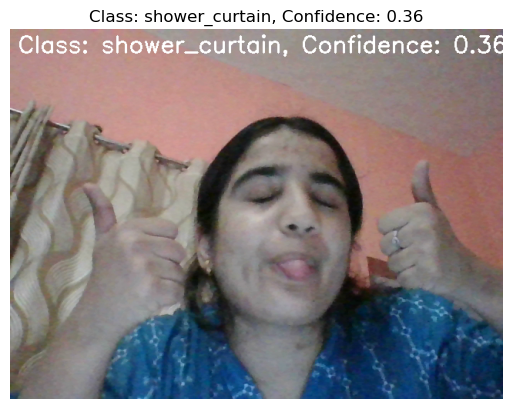

error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:1367: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvWaitKey'


In [71]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input, decode_predictions
import matplotlib.pyplot as plt

# Load the MobileNetV2 model
model = MobileNetV2(weights='imagenet')

# Initialize the webcam
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

# Define the image size expected by the model
IMG_SIZE = 224

def classify_frame(frame):
    # Resize the frame to match the input size of the model (224x224)
    img = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Preprocess the image
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)

    # Perform prediction
    preds = model.predict(img)
    
    # Decode and return the top prediction
    decoded_preds = decode_predictions(preds, top=1)[0]
    label = decoded_preds[0][1]  # Get the class label
    confidence = decoded_preds[0][2]  # Get the confidence score
    return label, confidence

# Create a Matplotlib figure for displaying the frames
plt.ion()  # Turn on interactive mode
fig, ax = plt.subplots()

while True:
    # Capture frame-by-frame from the webcam
    ret, frame = cap.read()
    
    if not ret:
        print("Error: Failed to capture image.")
        break

    # Classify the frame
    label, confidence = classify_frame(frame)

    # Display the prediction on the frame
    text = f"Class: {label}, Confidence: {confidence:.2f}"
    cv2.putText(frame, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

    # Convert frame for Matplotlib
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

    # Update the Matplotlib plot
    ax.clear()  # Clear the previous frame
    ax.imshow(frame_rgb)  # Display the current frame
    ax.set_title(text)  # Set the title with the prediction
    ax.axis('off')  # Hide axes
    plt.pause(0.001)  # Small pause to update the plot

    # Exit the loop when 'q' is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the webcam
cap.release()
plt.ioff()  # Turn off interactive mode
plt.show()  # Show the final frame before closing


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


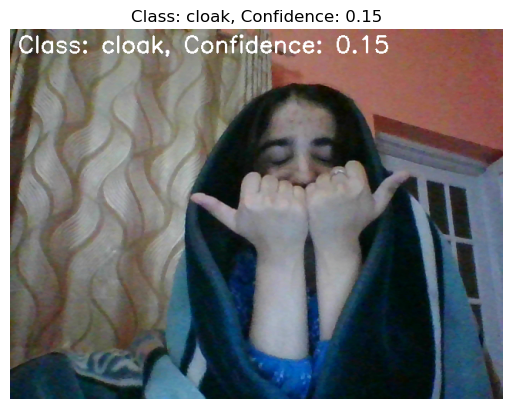

In [43]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input, decode_predictions
import matplotlib.pyplot as plt

# Load the MobileNetV2 model
model = MobileNetV2(weights='imagenet')

# Initialize the webcam
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

# Define the image size expected by the model
IMG_SIZE = 224

def classify_frame(frame):
    # Resize the frame to match the input size of the model (224x224)
    img = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Preprocess the image
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)

    # Perform prediction
    preds = model.predict(img)
    
    # Decode and return the top prediction
    decoded_preds = decode_predictions(preds, top=1)[0]
    label = decoded_preds[0][1]  # Get the class label
    confidence = decoded_preds[0][2]  # Get the confidence score
    return label, confidence

# Create a Matplotlib figure for displaying the frames
plt.ion()  # Turn on interactive mode
fig, ax = plt.subplots()

def on_key(event):
    if event.key == 'q':
        plt.close(fig)

# Connect the key event to the Matplotlib figure
fig.canvas.mpl_connect('key_press_event', on_key)

while True:
    # Capture frame-by-frame from the webcam
    ret, frame = cap.read()
    
    if not ret:
        print("Error: Failed to capture image.")
        break

    # Classify the frame
    label, confidence = classify_frame(frame)

    # Display the prediction on the frame
    text = f"Class: {label}, Confidence: {confidence:.2f}"
    cv2.putText(frame, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

    # Convert frame for Matplotlib
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

    # Update the Matplotlib plot
    ax.clear()  # Clear the previous frame
    ax.imshow(frame_rgb)  # Display the current frame
    ax.set_title(text)  # Set the title with the prediction
    ax.axis('off')  # Hide axes
    plt.pause(0.001)  # Small pause to update the plot

    # Exit the loop if the figure is closed (by pressing 'q')
    if not plt.fignum_exists(fig.number):
        break

# Release the webcam
cap.release()
plt.ioff()  # Turn off interactive mode
plt.show()  # Show the final frame before closing


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


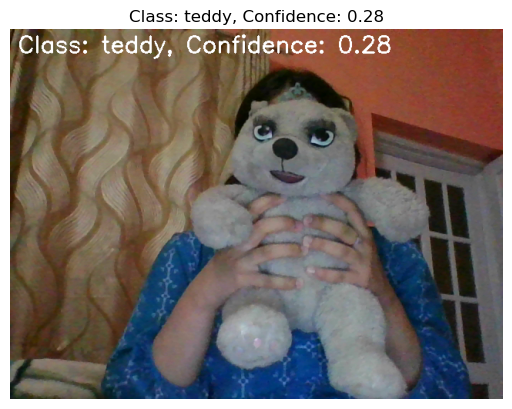

In [52]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input, decode_predictions
import matplotlib.pyplot as plt

# Load the MobileNetV2 model
model = MobileNetV2(weights='imagenet')

# Initialize the webcam
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

# Define the image size expected by the model
IMG_SIZE = 224

def classify_frame(frame):
    # Resize the frame to match the input size of the model (224x224)
    img = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Preprocess the image
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)

    # Perform prediction
    preds = model.predict(img)
    
    # Decode and return the top prediction
    decoded_preds = decode_predictions(preds, top=1)[0]
    label = decoded_preds[0][1]  # Get the class label
    confidence = decoded_preds[0][2]  # Get the confidence score
    return label, confidence

# Create a Matplotlib figure for displaying the frames
plt.ion()  # Turn on interactive mode
fig, ax = plt.subplots()

def on_key(event):
    if event.key == 'q':
        plt.close(fig)

# Connect the key event to the Matplotlib figure
fig.canvas.mpl_connect('key_press_event', on_key)

while True:
    # Capture frame-by-frame from the webcam
    ret, frame = cap.read()
    
    if not ret:
        print("Error: Failed to capture image.")
        break

    # Classify the frame
    label, confidence = classify_frame(frame)

    # Display the prediction on the frame
    text = f"Class: {label}, Confidence: {confidence:.2f}"
    cv2.putText(frame, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

    # Convert frame for Matplotlib
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

    # Update the Matplotlib plot
    ax.clear()  # Clear the previous frame
    ax.imshow(frame_rgb)  # Display the current frame
    ax.set_title(text)  # Set the title with the prediction
    ax.axis('off')  # Hide axes
    plt.pause(0.001)  # Small pause to update the plot

    # Exit the loop if the figure is closed (by pressing 'q')
    if not plt.fignum_exists(fig.number):
        break

# Release the webcam
cap.release()
plt.ioff()  # Turn off interactive mode
plt.show()  # Show the final frame before closing


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


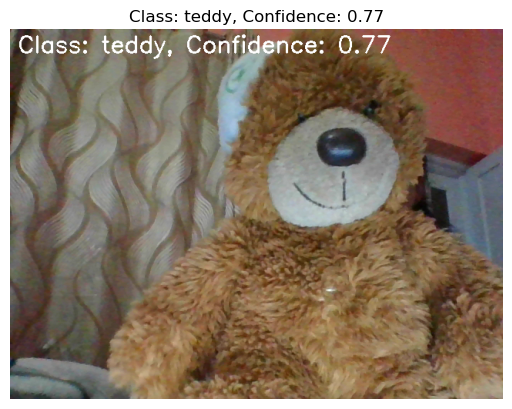

In [54]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input, decode_predictions
import matplotlib.pyplot as plt

# Load the MobileNetV2 model
model = MobileNetV2(weights='imagenet')

# Initialize the webcam
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

# Define the image size expected by the model
IMG_SIZE = 224

def classify_frame(frame):
    # Resize the frame to match the input size of the model (224x224)
    img = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Preprocess the image
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)

    # Perform prediction
    preds = model.predict(img)
    
    # Decode and return the top prediction
    decoded_preds = decode_predictions(preds, top=1)[0]
    label = decoded_preds[0][1]  # Get the class label
    confidence = decoded_preds[0][2]  # Get the confidence score
    return label, confidence

# Create a Matplotlib figure for displaying the frames
plt.ion()  # Turn on interactive mode
fig, ax = plt.subplots()

def on_key(event):
    if event.key == 'q':
        plt.close(fig)

# Connect the key event to the Matplotlib figure
fig.canvas.mpl_connect('key_press_event', on_key)

while True:
    # Capture frame-by-frame from the webcam
    ret, frame = cap.read()
    
    if not ret:
        print("Error: Failed to capture image.")
        break

    # Classify the frame
    label, confidence = classify_frame(frame)

    # Display the prediction on the frame
    text = f"Class: {label}, Confidence: {confidence:.2f}"
    cv2.putText(frame, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

    # Convert frame for Matplotlib
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

    # Update the Matplotlib plot
    ax.clear()  # Clear the previous frame
    ax.imshow(frame_rgb)  # Display the current frame
    ax.set_title(text)  # Set the title with the prediction
    ax.axis('off')  # Hide axes
    plt.pause(0.001)  # Small pause to update the plot

    # Exit the loop if the figure is closed (by pressing 'q')
    if not plt.fignum_exists(fig.number):
        break

# Release the webcam
cap.release()
plt.ioff()  # Turn off interactive mode
plt.show()  # Show the final frame before closing


In [12]:
import cv2
import torch
import torchvision.transforms as transforms
from torchvision.models import mobilenet_v2
import numpy as np
import matplotlib.pyplot as plt

# Load the pretrained MobileNetV2 model
model = mobilenet_v2(pretrained=True)
model.eval()

# Define the image transformations (matching the preprocessing expected by MobileNetV2)
preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Initialize the webcam
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

# Create a Matplotlib figure for displaying the frames
plt.ion()  # Turn on interactive mode
fig, ax = plt.subplots()

def classify_frame(frame):
    # Apply preprocessing to the frame
    img_tensor = preprocess(frame).unsqueeze(0)  # Add batch dimension
    
    # Perform the forward pass and obtain predictions
    with torch.no_grad():
        preds = model(img_tensor)
    
    # Get the class with the highest score
    predicted_class = preds.argmax(dim=1).item()
    confidence = torch.nn.functional.softmax(preds, dim=1)[0, predicted_class].item()
    
    return predicted_class, confidence

while True:
    # Capture frame-by-frame from the webcam
    ret, frame = cap.read()

    if not ret:
        print("Error: Failed to capture image.")
        break

    # Convert the frame to RGB (PyTorch models expect RGB input)
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Classify the frame
    label, confidence = classify_frame(frame_rgb)

    # Display the prediction on the frame
    text = f"Class: {label}, Confidence: {confidence:.2f}"

    # Update the Matplotlib plot
    ax.clear()  # Clear the previous frame
    ax.imshow(frame_rgb)  # Display the current frame
    ax.set_title(text)  # Set the title with the prediction
    ax.axis('off')  # Hide axes
    plt.draw()  # Update the plot in real-time
    plt.pause(0.001)  # Small pause to allow display refresh

    # Exit on pressing 'q'
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the webcam and close the plot
cap.release()
plt.ioff()
plt.close()


Error: Failed to capture image.
